# ****LEVEL-1****

## **Task 1: Data Loading and Initial Exploration**
This notebook explores restaurant data to understand ratings, missing values, city distribution, pricing, delivery patterns, and cuisine popularity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("cognifyz_Dataset.csv")

In [3]:
print(df.head())
print(df.tail())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [4]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant Name',
 'Country Code',
 'City',
 'Address',
 'Locality',
 'Locality Verbose',
 'Longitude',
 'Latitude',
 'Cuisines',
 'Average Cost for two',
 'Currency',
 'Has Table booking',
 'Has Online delivery',
 'Is delivering now',
 'Switch to order menu',
 'Price range',
 'Aggregate rating',
 'Rating color',
 'Rating text',
 'Votes']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [6]:
# Check missing values as part of initial exploration
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


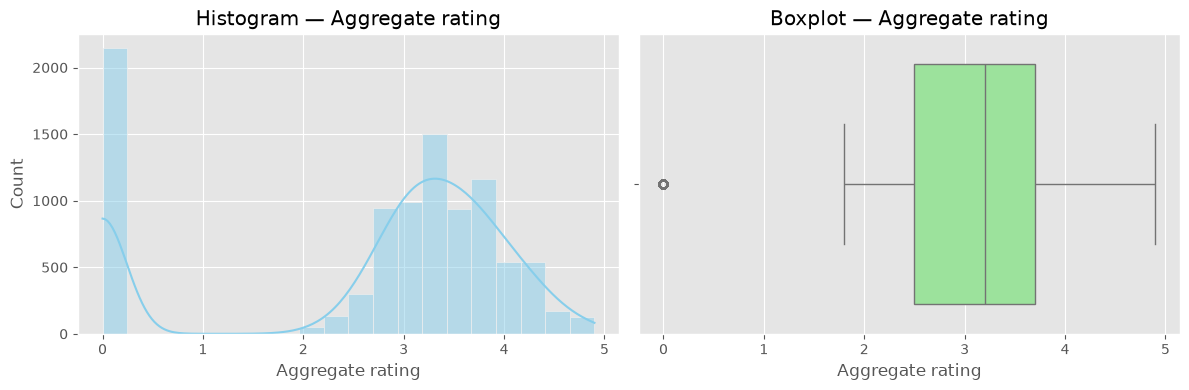

In [7]:
# Aggregate rating exploration as part of initial exploration
print(df["Aggregate rating"].describe())
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(pd.to_numeric(df["Aggregate rating"], errors="coerce"), bins=20, kde=True, color="skyblue")
plt.title("Histogram — Aggregate rating")
plt.xlabel("Aggregate rating")

plt.subplot(1,2,2)
sns.boxplot(x=pd.to_numeric(df["Aggregate rating"], errors="coerce"), color="lightgreen")
plt.title("Boxplot — Aggregate rating")
plt.xlabel("Aggregate rating")

plt.tight_layout()
plt.show()

## **Task 2: Descriptive Analysis**
This section performs descriptive statistics and categorical distribution analysis for the restaurant dataset.

In [8]:
# Calculate detailed numeric statistics for all numeric columns
import numpy as np

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
stats = []
for col in numeric_cols:
	series = pd.to_numeric(df[col], errors="coerce")
	stats.append({
		"column": col,
		"count": int(series.count()),
		"mean": float(np.nanmean(series)),
		"median": float(np.nanmedian(series)),
		"std": float(np.nanstd(series, ddof=1)),
		"min": float(np.nanmin(series)),
		"max": float(np.nanmax(series))
	})

stats_df = pd.DataFrame(stats)
display(stats_df)
# save a copy for reference
stats_df.to_csv("numeric_stats.csv", index=False)

,column,count,mean,median,std,min,max
0,Restaurant ID,9551,9.051128e+06,6.004089e+06,8.791521e+06,53.000000,1.850065e+07
1,Country Code,9551,1.836562e+01,1.000000e+00,5.675055e+01,1.000000,2.160000e+02
2,Longitude,9551,6.412657e+01,7.719196e+01,4.146706e+01,-157.948486,1.748321e+02
3,Latitude,9551,2.585438e+01,2.857047e+01,1.100794e+01,-41.330428,5.597698e+01
4,Average Cost for two,9551,1.199211e+03,4.000000e+02,1.612118e+04,0.000000,8.000000e+05
5,Price range,9551,1.804837e+00,2.000000e+00,9.056088e-01,1.000000,4.000000e+00
6,Aggregate rating,9551,2.666370e+00,3.200000e+00,1.516378e+00,0.000000,4.900000e+00
7,Votes,9551,1.569097e+02,3.100000e+01,4.301691e+02,0.000000,1.093400e+04


In [9]:
# Count restaurants by Country Code
country_counts = df["Country Code"].value_counts()
country_counts.head(10)

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64

In [10]:
# Count restaurants by City
city_counts = df["City"].value_counts().head(10)
city_counts

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

In [11]:
# Count of top cuisines
cuisines = df["Cuisines"].dropna().str.split(",").explode().str.strip()
top_cuisines = cuisines.value_counts().head(10)
top_cuisines

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

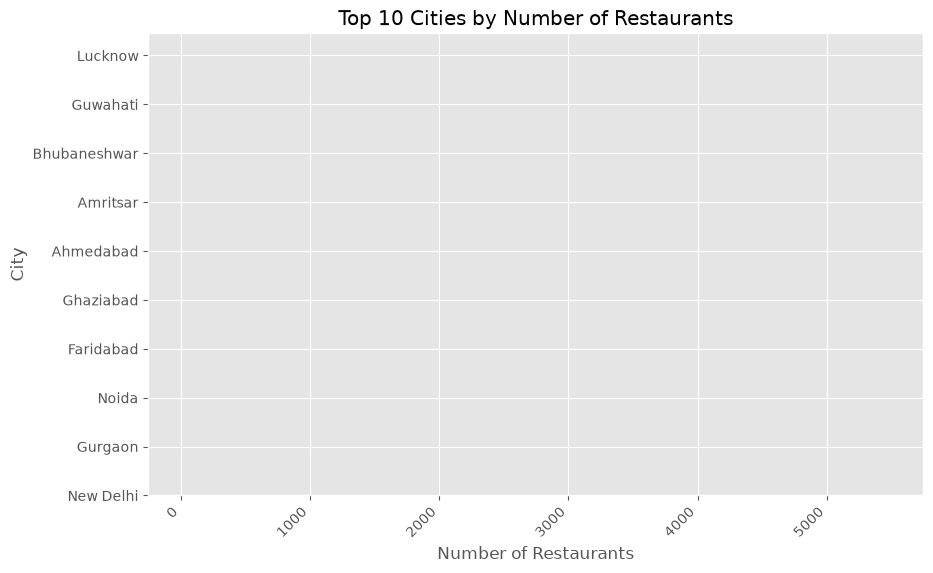

In [12]:
# Plot top 10 cities by restaurant count
plt.figure(figsize=(10,6))
city_counts = df["City"].value_counts().head(10)
plt.bar(city_counts.values,city_counts.index, color="skyblue")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.xticks(rotation=45,ha="right")
plt.show()

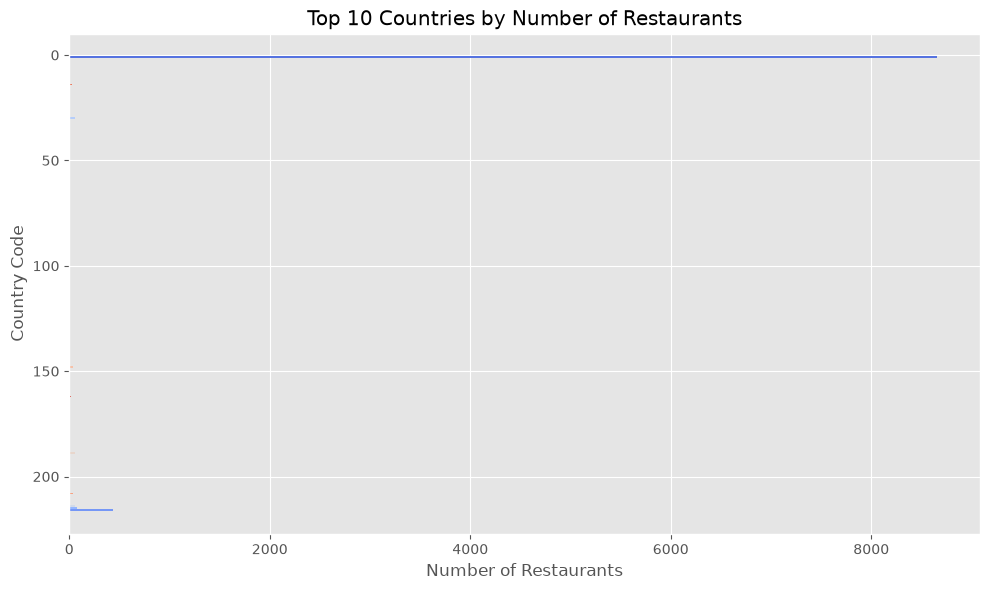

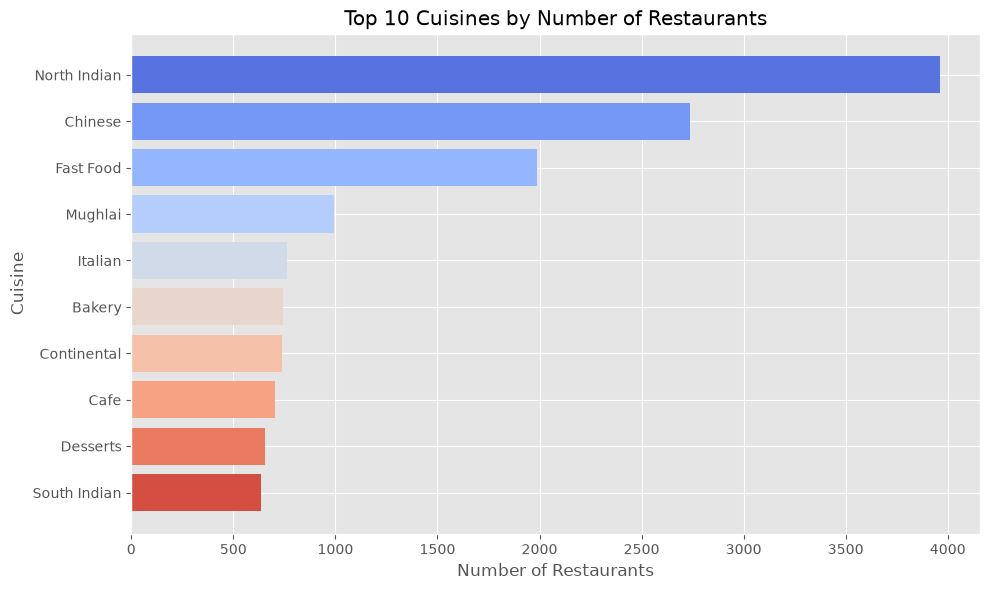

Numeric columns analyzed: ['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']


,count,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average Cost for two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Price range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04


In [13]:
# Plot top countries by restaurant count
plt.figure(figsize=(10,6))
country_counts = df["Country Code"].value_counts().head(10)
colors = sns.color_palette("coolwarm", len(country_counts))
plt.barh(country_counts.index, country_counts.values, color=colors)
plt.title("Top 10 Countries by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Country Code")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot top cuisines by frequency
plt.figure(figsize=(10,6))
top_cuisines = df["Cuisines"].dropna().str.split(",").explode().str.strip().value_counts().head(10)
colors = sns.color_palette("coolwarm", len(top_cuisines))
plt.barh(top_cuisines.index, top_cuisines.values, color=colors)
plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Descriptive statistics for all numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Numeric columns analyzed:", numeric_cols)
all_numeric_stats = df[numeric_cols].describe().T
display(all_numeric_stats)


## **Task 2 Summary**
- Numeric descriptive statistics were calculated for the dataset numerical columns.
- Categorical distributions were explored for `Country Code`, `City`, and `Cuisines`.
- Top cuisines and top cities were identified by restaurant count.
- Task 2 remains focused on descriptive analysis only.


## **Task 3: Geospatial Analysis**
This section will visualize restaurant locations using latitude and longitude, and analyze spatial patterns in ratings and distributions.

Valid geospatial records: 9551


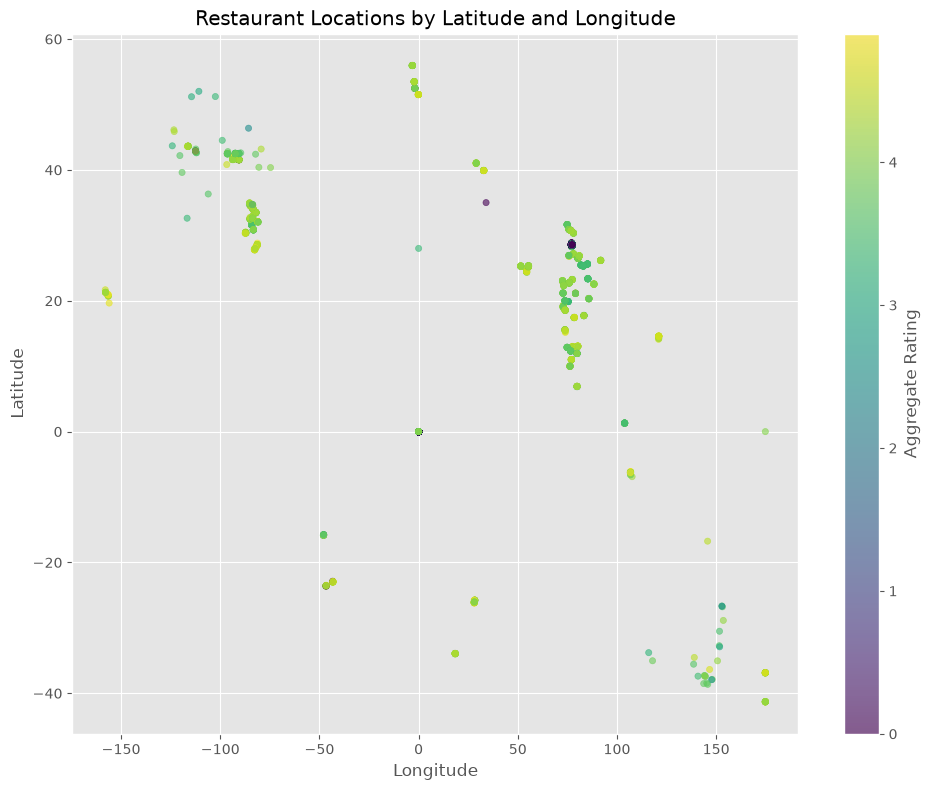

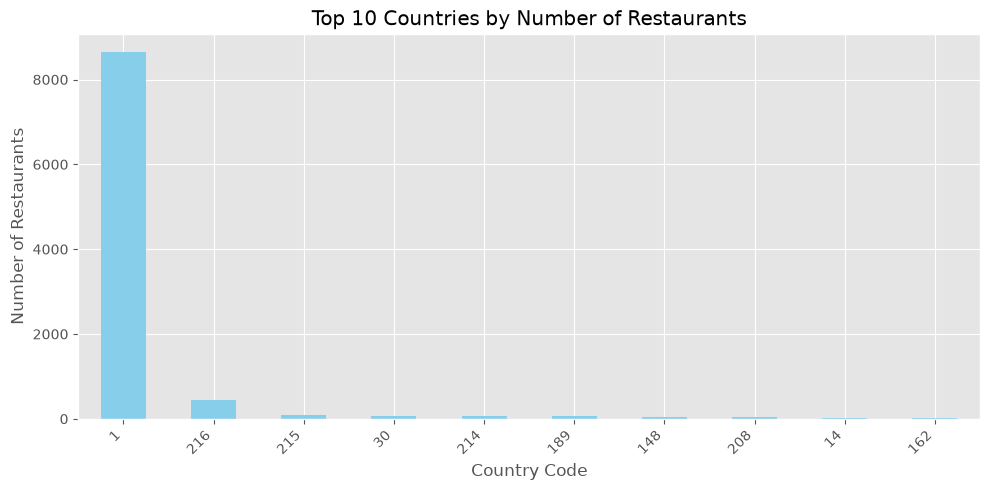

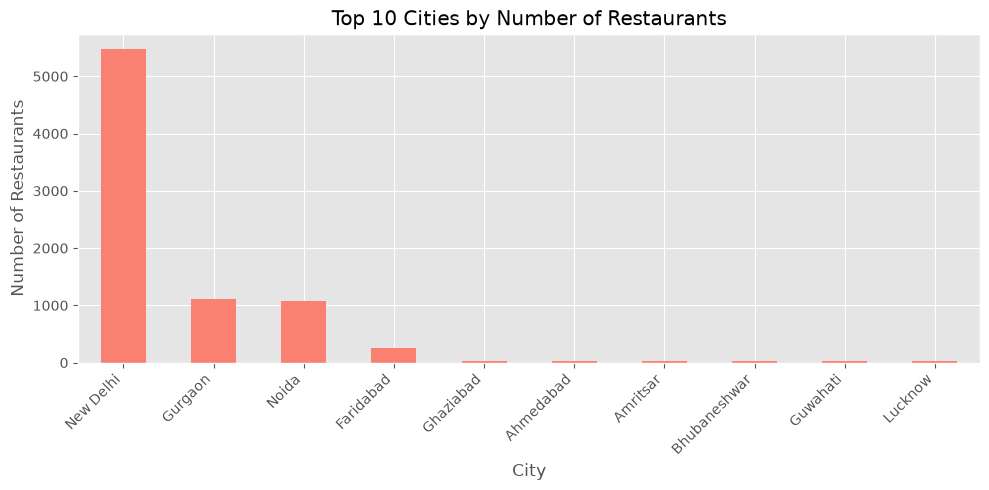

Latitude-rating correlation: 0.001
Longitude-rating correlation: -0.117
Average rating for top cities:


City
New Delhi       2.44
Gurgaon         2.65
Noida           2.04
Faridabad       1.87
Ghaziabad       2.85
Ahmedabad       4.16
Amritsar        3.69
Bhubaneshwar    3.98
Guwahati        4.19
Lucknow         4.20
Name: Aggregate rating, dtype: float64

In [14]:
# Task 3: Geospatial Analysis
geo_df = df.copy()
geo_df["Latitude"] = pd.to_numeric(geo_df["Latitude"], errors="coerce")
geo_df["Longitude"] = pd.to_numeric(geo_df["Longitude"], errors="coerce")
geo_df["Aggregate rating"] = pd.to_numeric(geo_df["Aggregate rating"], errors="coerce")
geo_df = geo_df.dropna(subset=["Latitude", "Longitude", "Aggregate rating"])
print("Valid geospatial records:", len(geo_df))

plt.figure(figsize=(10,8))
plt.scatter(
    geo_df["Longitude"],
    geo_df["Latitude"],
    c=geo_df["Aggregate rating"],
    cmap="viridis",
    s=20,
    alpha=0.6
)
plt.colorbar(label="Aggregate Rating")
plt.title("Restaurant Locations by Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

top_countries = geo_df["Country Code"].value_counts().head(10)
top_cities = geo_df["City"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar", color="skyblue")
plt.title("Top 10 Countries by Number of Restaurants")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar", color="salmon")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Latitude-rating correlation:", round(geo_df["Latitude"].corr(geo_df["Aggregate rating"]), 3))
print("Longitude-rating correlation:", round(geo_df["Longitude"].corr(geo_df["Aggregate rating"]), 3))

top_city_ratings = geo_df.groupby("City")["Aggregate rating"].mean().loc[top_cities.index]
print("Average rating for top cities:")
display(top_city_ratings.round(2))


## **Task 3 Summary**
- Geospatial analysis used Latitude and Longitude to map restaurant locations.
- Top countries and top cities were identified by restaurant count.
- Basic location-rating correlation was computed for latitude and longitude.
- Average ratings were reported for the most common cities.


## **Final Conclusion**
- Task 1 loaded the restaurant dataset, checked missing values, and explored the `Aggregate rating` distribution.
- Task 2 performed descriptive statistics on numeric features and analyzed categorical distributions for `Country Code`, `City`, and `Cuisines`.
- Task 3 visualized restaurant locations using latitude and longitude, identified top cities and countries, and examined simple rating-location correlations.
- The combined analysis provides a clear overview of restaurant distribution, rating trends, and geographic patterns in the dataset.
